In [1]:
import torch                 # main PyTorch library
import torch.nn as nn        # neural‑network modules (Linear, Loss, etc.)
import numpy as np           
import matplotlib.pyplot as plt  


# Linear Regression


In [4]:
# Data Description: Here we simulate data from y = 0.5 x − 1 with Gaussian noise
N = 20 # Number of data points

# Generate random inputs X uniformly between −5 and +5
X = np.random.random(N)*10 -5 

# Generate targets Y following roughly the linear rule: Y ≈ 0.5 * X − 1 + noise
Y = 0.5 * X -1 + np.random.randn(N)

In [5]:
X.shape

(20,)

In [6]:
Y.shape

(20,)

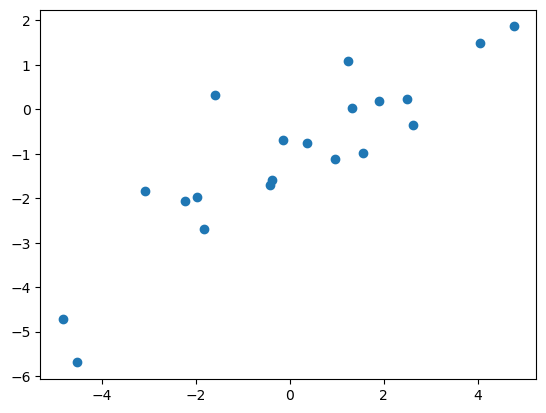

In [7]:
plt.scatter(X,Y);

In a **Linear Regression** or any PyTorch model expecting a tensor with shape `(batch_size, in_features)`,
we must express each sample (data point) as a **row vector**,  and the total number of samples as **rows**.


In [8]:
# Reshape NumPy arrays to column‑vectors of shape (N, 1)
X = X.reshape(N, 1)
Y = Y.reshape(N, 1)

In [9]:
X.shape

(20, 1)

In [10]:
Y.shape

(20, 1)

In [11]:
# Define a simple linear model: ŷ = w*x + b
model = nn.Linear(1, 1)

The function **`nn.Linear(in_features=1, out_features=1)`** creates a simple *fully connected layer* that learns two parameters:

- **weight `w`**
- **bias `b`**

$$
\hat{y} = x \times w^T + b
$$

Here:

- x is the input tensor with shape (N, 1) → N samples, 1 feature.
- w is the weight tensor with shape (1, 1).
- b is the bias tensor with shape (1,).



In [12]:
# Convert NumPy arrays to PyTorch tensors (dtype float32)
inputs = torch.from_numpy(X.astype(np.float32))
targets = torch.from_numpy(Y.astype(np.float32))

In [13]:
(inputs.shape, targets.shape)

(torch.Size([20, 1]), torch.Size([20, 1]))

In [14]:
# Define loss function: Mean Squared Error
criterion = nn.MSELoss()

**Mean Squared Error (MSE)**

$$
\text{MSE} = \text{mean}\left( (\hat{y} - y)^2 \right)
$$

This metric measures how far predictions ($\hat{y}$)  are from the true target values ($y$) .  
It squares the error for each sample, averages all squared differences, and returns a single scalar representing overall prediction quality.



In [15]:
# Define optimizer: Stochastic Gradient Descent (SGD)
optimizer = torch.optim.SGD(model.parameters(), lr=0.1)

In [16]:
# Print all parameter tensors
for p in model.parameters():
    print(p)

Parameter containing:
tensor([[-0.6378]], requires_grad=True)
Parameter containing:
tensor([-0.7086], requires_grad=True)


In [17]:
n_epochs = 30       # number of passes through the dataset
# Each “epoch” means one full forward & backward pass through all training samples.

losses = []         # track loss values for plotting later

for it in range(n_epochs):
    optimizer.zero_grad()
    # Important step: by default, gradients accumulate in PyTorch.
    # We clear old gradients before computing new ones.

    outputs = model(inputs)
    # Forward pass — computes predictions \hat{y}=wx+b for all 20 samples.

    loss = criterion(outputs, targets)
    # Compute MSE loss between predictions and ground‑truth targets.

    losses.append(loss.item())
    # .item() extracts the numeric value (Python float) from a tensor,

    loss.backward()
    # Back‑propagation: compute ∂loss/∂w and ∂loss/∂b automatically.

    optimizer.step()
    # w ---> w − lr × ∂loss/∂w
    # b ---> b − lr × ∂loss/∂b

    print(f'Epoch {it+1}/{n_epochs}, Loss: {loss.item(): 4f}')
    # Monitor training progress — loss should gradually decrease.




Epoch 1/30, Loss:  11.396840
Epoch 2/30, Loss:  1.874971
Epoch 3/30, Loss:  0.937508
Epoch 4/30, Loss:  0.831769
Epoch 5/30, Loss:  0.811467
Epoch 6/30, Loss:  0.803014
Epoch 7/30, Loss:  0.798039
Epoch 8/30, Loss:  0.794897
Epoch 9/30, Loss:  0.792890
Epoch 10/30, Loss:  0.791605
Epoch 11/30, Loss:  0.790784
Epoch 12/30, Loss:  0.790258
Epoch 13/30, Loss:  0.789921
Epoch 14/30, Loss:  0.789705
Epoch 15/30, Loss:  0.789567
Epoch 16/30, Loss:  0.789479
Epoch 17/30, Loss:  0.789423
Epoch 18/30, Loss:  0.789387
Epoch 19/30, Loss:  0.789363
Epoch 20/30, Loss:  0.789348
Epoch 21/30, Loss:  0.789339
Epoch 22/30, Loss:  0.789333
Epoch 23/30, Loss:  0.789329
Epoch 24/30, Loss:  0.789327
Epoch 25/30, Loss:  0.789325
Epoch 26/30, Loss:  0.789324
Epoch 27/30, Loss:  0.789323
Epoch 28/30, Loss:  0.789323
Epoch 29/30, Loss:  0.789323
Epoch 30/30, Loss:  0.789322


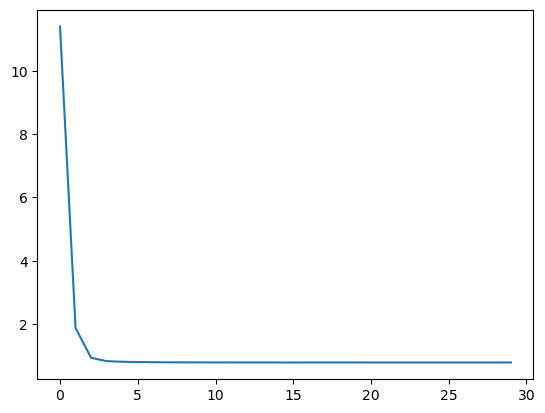

In [18]:
plt.plot(losses)


In [19]:
with torch.no_grad():
  predicted = model(inputs).numpy()
# torch.no_grad() disables Autograd tracking (faster inference).

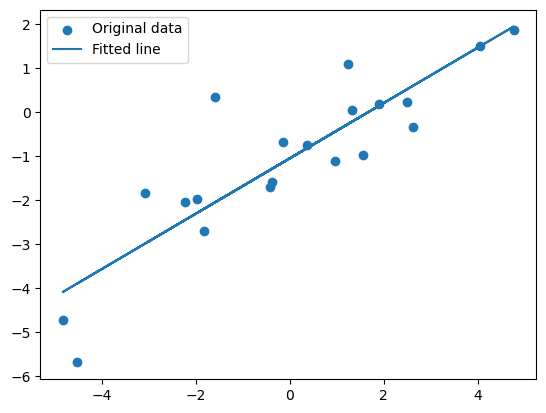

In [20]:
plt.scatter(X, Y, label='Original data')
plt.plot(X, predicted, label='Fitted line')
plt.legend()
plt.show()


In [21]:
w = model.weight.data.numpy()
b = model.bias.data.numpy()
print(w, b)


[[0.6286927]] [-1.0594573]


## Saving and Loading Models in PyTorch
---
After training a model, you generally want to **save** it so you can use it later without retraining.  
PyTorch provides flexible ways to store either the **parameters (weights/biases)** or the entire **model object**.

---


### 1. Save **only the parameters**

This is the most common and stable way.
```python
torch.save(model.state_dict(), "model_weights.pth")


**state_dict() returns a dictionary containing all learnable parameters (weights, biases)**


In [ ]:
model.state_dict()

OrderedDict([('weight', tensor([[0.4274]])), ('bias', tensor([-1.0130]))])

**Important: You must define the same architecture before loading state_dict()**

In [22]:
torch.save(model.state_dict(), 'test_model.pt')

In [23]:
model_loaded = nn.Linear(1, 1)
model_loaded.load_state_dict(torch.load('test_model.pt'))

<All keys matched successfully>

In [24]:
model_loaded

Linear(in_features=1, out_features=1, bias=True)

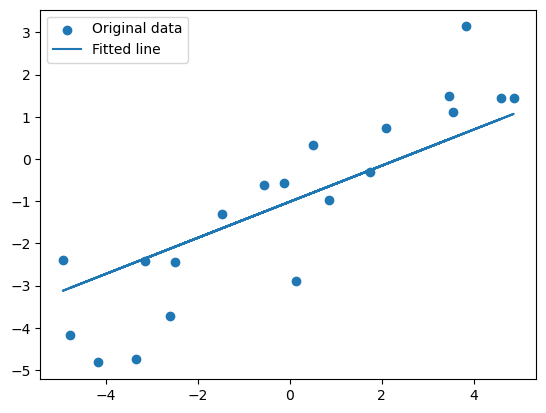

In [27]:
with torch.no_grad():
  predicted = model_loaded(inputs).numpy()
# torch.no_grad() disables Autograd tracking (faster inference).
plt.scatter(X, Y, label='Original data')
plt.plot(X, predicted, label='Fitted line')
plt.legend()
plt.show()

### 2.  Save **entire model** object — Quick but less flexible

This method saves both the weights and the model structure.

While convenient, this approach can break if:

- You change Python code where the model class was defined,
- Or move the file between different PyTorch versions.

Hence, use the state_dict method for long-term projects.

In [29]:
torch.save(model, "full_model.pth")

In [2]:
model_loaded_v2 = torch.load("full_model.pth")

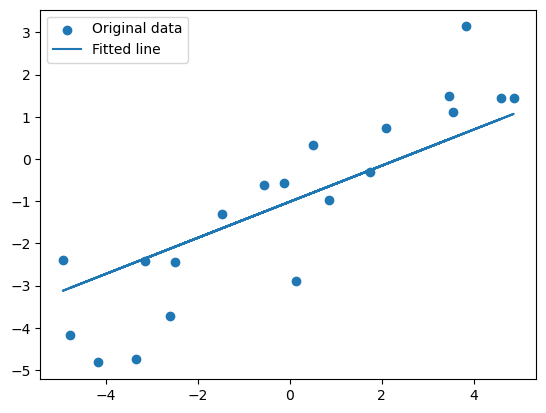

In [32]:
with torch.no_grad():
  predicted = model_loaded_v2(inputs).numpy()
# torch.no_grad() disables Autograd tracking (faster inference).
plt.scatter(X, Y, label='Original data')
plt.plot(X, predicted, label='Fitted line')
plt.legend()
plt.show()

### 3.  Convert model to **TorchScript** — Robust and deployment‑ready

This method compiles the model into an independent execution graph that contains both its structure and trained weights.

Unlike Python‑based saving, TorchScript models run without requiring the original class definition, and can be loaded directly in C++ (LibTorch) or mobile runtimes.

Ideal for production use or cross‑platform inference environments.

In [23]:
example_input = torch.randn(1, 1)
scripted_model = torch.jit.trace(model, example_input)
scripted_model.save("traced_model.pt")

In [24]:
loaded_model = torch.jit.load("traced_model.pt")

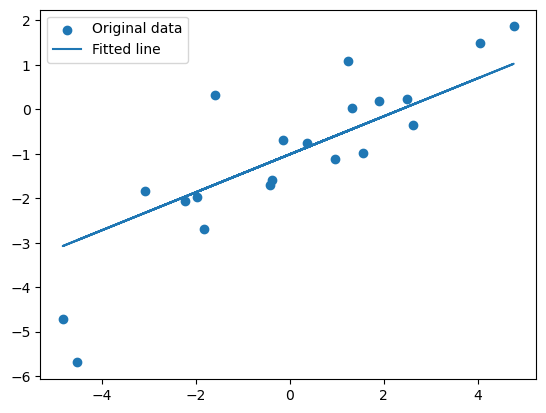

In [26]:
with torch.no_grad():
  predicted = model_loaded_v2(inputs).numpy()
# torch.no_grad() disables Autograd tracking (faster inference).
plt.scatter(X, Y, label='Original data')
plt.plot(X, predicted, label='Fitted line')
plt.legend()
plt.show()

# Beyond the Linear Regression

Problem Statement
--

We aim to construct a **nonlinear neural network** that models a **velocity field** as a function of space and time.  
Formally, the model represents a mapping:

$$
f_\theta : (x, y, z, t) \rightarrow (u, v, w)
$$

where:

- **Inputs** — four-dimensional vector  
  representing spatial coordinates and temporal position:
  $$
  [x, y, z, t]
  $$

- **Outputs** — three-dimensional velocity field components:
  $$
  [u, v, w]
  $$

The goal is to learn this nonlinear relationship using a **feedforward neural network (MLP)**.

---

## Model Architecture

Following the attached network diagram, we design a fully connected architecture using  
**`torch.nn.Sequential`** in PyTorch (without defining a class):

| Layer | Mapping | Activation | Description |
|--------|----------|-------------|-------------|
| 1 | 4 → 10 | ReLU | Expand spatial-temporal features |
| 2 | 10 → 10 | ReLU | Capture nonlinear interactions |
| 3 | 10 → 3 | — | Map hidden representation to velocity output |
---

![alt text](image.png)

In [ ]:
# Build nonlinear model without defining a class
# According to loaded diagram: 4 → 10 → 10 → 3 (fully connected network)
model = nn.Sequential(
    nn.Linear(4, 10),      # input: (x, y, z, t)
    nn.ReLU(),
    nn.Linear(10, 10),
    nn.ReLU(),
    nn.Linear(10, 3)       # output: (u, v, w)
)

# data for test
inputs = torch.randn(1000, 4)
targets = torch.randn(1000, 3)

# Loss and optimizer
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)

# Training loop
for epoch in range(200):
    optimizer.zero_grad()
    outputs = model(inputs)
    loss = criterion(outputs, targets)
    loss.backward()
    optimizer.step()

    if epoch % 20 == 0:
        print(f"Epoch {epoch}: Loss = {loss.item():.6f}")


Class-Based Implementation
--

This version defines the nonlinear **velocity field model** using a **custom PyTorch class** derived from `nn.Module`.  
Compared to `nn.Sequential`, it allows full flexibility for complex architectures and is ideal for scientific modeling tasks.



In [ ]:
class VelocityFieldModel(nn.Module):
    def __init__(self):
        super(VelocityFieldModel, self).__init__()

        # Fully connected layers
        self.layer1 = nn.Linear(4, 10)   # Input layer: 4 features -> 10 neurons
        self.layer2 = nn.Linear(10, 10)  # Hidden layer: 10 -> 10 neurons
        self.layer3 = nn.Linear(10, 3)   # Output layer: 10 -> 3 velocity components

        # Activation function
        self.activation = nn.ReLU()

    def forward(self, x):
        """
        Forward pass through the network.
        Applies ReLU activation after each hidden layer.
        """
        x = self.activation(self.layer1(x))
        x = self.activation(self.layer2(x))
        x = self.layer3(x)
        return x